# Prédiction des prix immobiliers à Nancy

**Projet Data Science / Machine Learning**

Objectif : construire et comparer des modèles capables de prédire le prix de vente d'un bien immobilier (maison ou appartement) à partir de ses caractéristiques : surface, nombre de pièces, type de bien, localisation (coordonnées GPS) et année de la transaction.

## Origine des données

Les données utilisées sont les **DVF (Demandes de Valeurs Foncières)**, publiées en open data par la Direction Générale des Finances Publiques sur [data.gouv.fr](https://files.data.gouv.fr/geo-dvf/latest/csv/). Elles recensent les transactions immobilières réellement enregistrées en France.

**Pourquoi Nancy et pas Metz ?** Metz se situe en Alsace-Moselle, un territoire soumis au régime du **Livre Foncier** plutôt qu'à la publicité foncière classique : il n'existe donc pas de données DVF publiques pour Metz. Nancy, ville la plus proche disposant de données DVF complètes (même région Grand Est, ~50 km de Metz), a été retenue à la place.

Les données couvrent les transactions de **2021 à 2024** dans le département de la Meurthe-et-Moselle (54), filtrées sur la commune de Nancy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)


## 1. Chargement des données brutes (DVF, 2021-2024)

In [2]:
frames = []
for annee in [2021, 2022, 2023, 2024]:
    df_annee = pd.read_csv(f"dvf_54_{annee}.csv", low_memory=False)
    frames.append(df_annee)

df = pd.concat(frames, ignore_index=True)
print("Lignes totales (departement 54, 2021-2024) :", len(df))
df.head(3)


Lignes totales (departement 54, 2021-2024) : 182887


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-894583,2021-01-04,1,Vente,140000.0,38.0,NaN,RUE SERGENT BOBILLOT,4850,54000.0,54395,Nancy,54,NaN,NaN,54395000CH0219,NaN,NaN,2.0,72.68,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,73.0,3.0,NaN,NaN,NaN,NaN,NaN,6.160276,48.687366
1,2021-894583,2021-01-04,1,Vente,140000.0,38.0,NaN,RUE SERGENT BOBILLOT,4850,54000.0,54395,Nancy,54,NaN,NaN,54395000CH0219,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,6.160276,48.687366
2,2021-894584,2021-01-05,1,Vente,246000.0,26.0,NaN,CHE DE LA PEPINIERE,0160,54700.0,54279,Jezainville,54,NaN,NaN,54279000AC0353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,96.0,3.0,S,sols,NaN,NaN,404.0,6.036656,48.872333


## 2. Filtrage sur la commune de Nancy et sur les ventes

In [3]:
nancy = df[df["nom_commune"] == "Nancy"].copy()
print("Transactions a Nancy (toutes natures, tous types) :", len(nancy))

nancy["nature_mutation"].value_counts()


Transactions a Nancy (toutes natures, tous types) : 31389


nature_mutation
Vente                                 28821
Vente en l'état futur d'achèvement     2351
Echange                                 124
Expropriation                            53
Adjudication                             33
Vente terrain à bâtir                     7
Name: count, dtype: int64

In [4]:
nancy["type_local"].value_counts(dropna=False)


type_local
Dépendance                                  15435
Appartement                                 10813
NaN                                          2575
Local industriel. commercial ou assimilé     1625
Maison                                        941
Name: count, dtype: int64

On ne garde que :
- les **ventes** (`nature_mutation == "Vente"`), en excluant les échanges, expropriations, adjudications ;
- les **maisons et appartements** (`type_local`), en excluant dépendances et locaux commerciaux ;
- les lignes avec un prix et une surface renseignés ;
- une seule ligne par transaction (`id_mutation`), car une même vente peut apparaître sur plusieurs lignes DVF (dépendances, parcelles annexes).


In [5]:
nancy = nancy[nancy["nature_mutation"] == "Vente"]
nancy = nancy[nancy["type_local"].isin(["Maison", "Appartement"])]
nancy = nancy.dropna(subset=["valeur_fonciere", "surface_reelle_bati"])
nancy = nancy[nancy["surface_reelle_bati"] > 0]
nancy = nancy.drop_duplicates(subset=["id_mutation"])

nancy["annee_mutation"] = pd.to_datetime(nancy["date_mutation"]).dt.year
nancy["prix_m2"] = nancy["valeur_fonciere"] / nancy["surface_reelle_bati"]

print("Transactions apres filtrage :", len(nancy))
nancy[["valeur_fonciere", "surface_reelle_bati", "nombre_pieces_principales", "prix_m2"]].describe()


Transactions apres filtrage : 8887


,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,prix_m2
count,8.887000e+03,8887.000000,8887.000000,8887.000000
mean,1.797077e+05,66.167886,2.839316,3043.957963
std,2.790779e+05,39.013617,1.472783,5664.025576
min,1.000000e+00,1.000000,0.000000,0.007246
25%,8.600000e+04,39.000000,2.000000,1929.119168
50%,1.300000e+05,60.000000,3.000000,2369.565217
75%,2.099000e+05,84.000000,4.000000,2875.000000
max,2.083938e+07,528.000000,13.000000,234150.337079


## 3. Nettoyage des valeurs aberrantes

Le jeu DVF brut contient des ventes non représentatives du marché (cessions familiales à prix symbolique, ventes de quotes-parts, erreurs de saisie). On élimine le 1% le plus extrême de part et d'autre de la distribution du prix au m², ainsi que les surfaces manifestement erronées.


In [6]:
q_low = nancy["prix_m2"].quantile(0.01)
q_high = nancy["prix_m2"].quantile(0.99)

nancy_clean = nancy[
    (nancy["prix_m2"] >= q_low) & (nancy["prix_m2"] <= q_high) &
    (nancy["surface_reelle_bati"] >= 10) & (nancy["surface_reelle_bati"] <= 300) &
    (nancy["valeur_fonciere"] >= 10000)
].copy()

print(f"Bornes retenues pour le prix/m2 : [{q_low:.0f}, {q_high:.0f}] euros/m2")
print("Transactions conservees :", len(nancy_clean), "sur", len(nancy))


Bornes retenues pour le prix/m2 : [597, 16722] euros/m2
Transactions conservees : 8697 sur 8887


## 4. Analyse exploratoire des données (EDA)

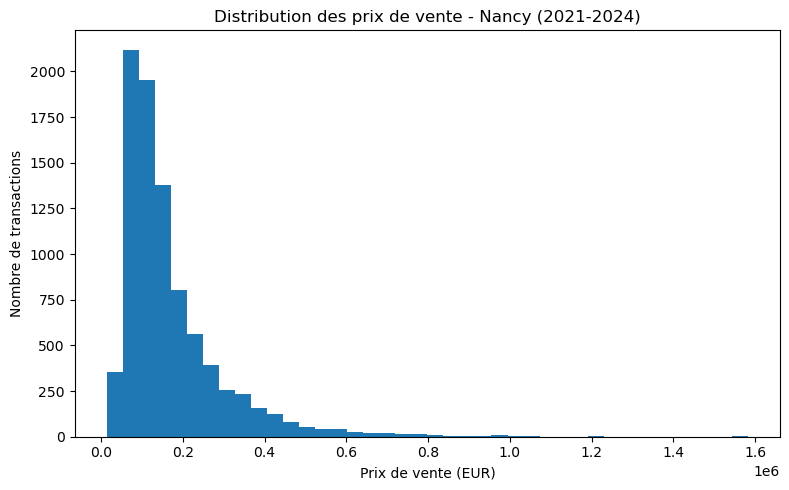

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(nancy_clean["valeur_fonciere"], bins=40)
plt.xlabel("Prix de vente (EUR)")
plt.ylabel("Nombre de transactions")
plt.title("Distribution des prix de vente - Nancy (2021-2024)")
plt.tight_layout()
plt.savefig("distribution_prix.png", dpi=120)
plt.show()


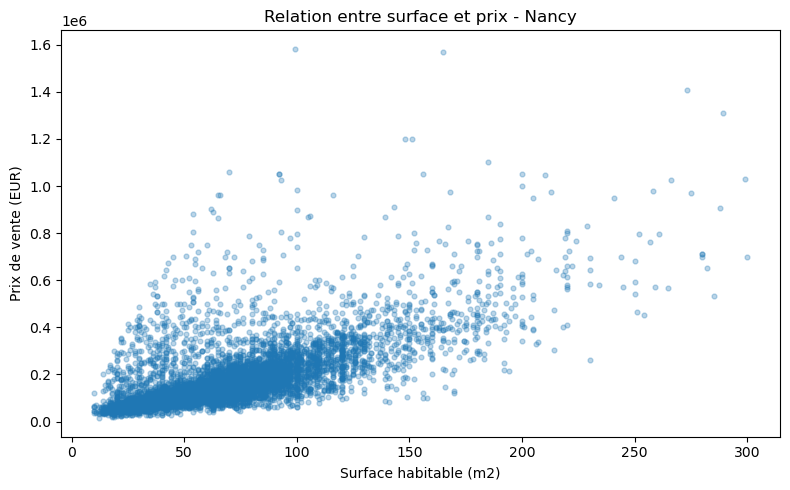

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(nancy_clean["surface_reelle_bati"], nancy_clean["valeur_fonciere"], alpha=0.3, s=12)
plt.xlabel("Surface habitable (m2)")
plt.ylabel("Prix de vente (EUR)")
plt.title("Relation entre surface et prix - Nancy")
plt.tight_layout()
plt.show()


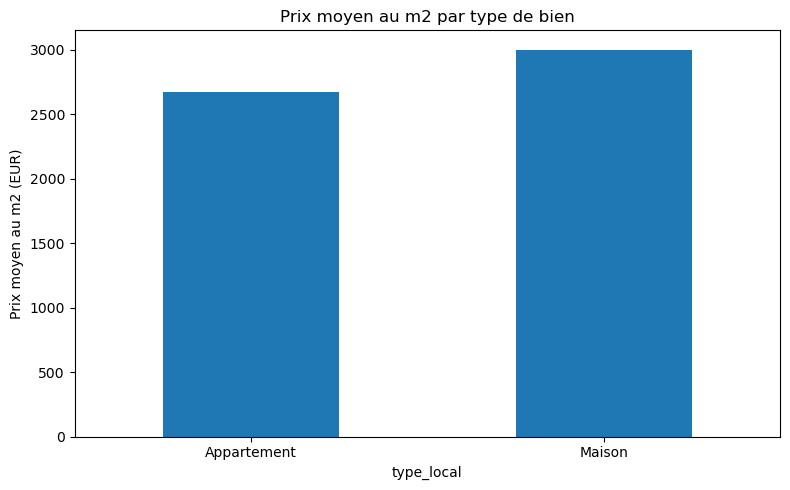

In [9]:
plt.figure(figsize=(8, 5))
nancy_clean.groupby("type_local")["prix_m2"].mean().plot(kind="bar")
plt.ylabel("Prix moyen au m2 (EUR)")
plt.title("Prix moyen au m2 par type de bien")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


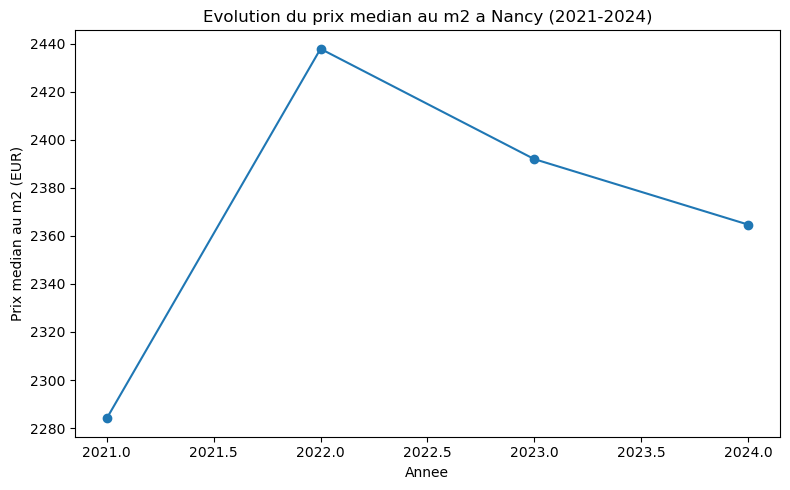

In [10]:
plt.figure(figsize=(8, 5))
nancy_clean.groupby("annee_mutation")["prix_m2"].median().plot(kind="line", marker="o")
plt.xlabel("Annee")
plt.ylabel("Prix median au m2 (EUR)")
plt.title("Evolution du prix median au m2 a Nancy (2021-2024)")
plt.tight_layout()
plt.show()


## 5. Préparation des données pour la modélisation

Le prix d'un bien suit une distribution très asymétrique (quelques biens très chers tirent la moyenne vers le haut). On entraîne donc les modèles sur le **logarithme du prix** (`log1p`), une transformation standard en économétrie immobilière, puis on revient à l'échelle euro (`expm1`) pour évaluer et présenter les résultats.

La localisation est capturée par la **longitude et la latitude** exactes du bien plutôt que par le seul code postal, qui est trop grossier (un même code postal couvre des quartiers très différents).


In [11]:
features = ["surface_reelle_bati", "nombre_pieces_principales", "type_local", "longitude", "latitude", "annee_mutation"]
target = "valeur_fonciere"

data_model = nancy_clean.dropna(subset=features + [target]).copy()

X = data_model[features]
y_log = np.log1p(data_model[target])
y_eur = data_model[target]

X_train, X_test, y_train_log, y_test_log, y_train_eur, y_test_eur = train_test_split(
    X, y_log, y_eur, test_size=0.2, random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)


Taille apprentissage : (6922, 6)
Taille test : (1731, 6)


In [12]:
numeric_features = ["surface_reelle_bati", "nombre_pieces_principales", "annee_mutation", "longitude", "latitude"]
categorical_features = ["type_local"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 6. Modèle 1 — Régression linéaire (sur le prix log-transformé)

In [13]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train_log)
linear_pred_eur = np.expm1(linear_model.predict(X_test))

linear_mae = mean_absolute_error(y_test_eur, linear_pred_eur)
linear_rmse = np.sqrt(mean_squared_error(y_test_eur, linear_pred_eur))
linear_r2 = r2_score(y_test_eur, linear_pred_eur)

print("Regression lineaire (log-prix)")
print(f"MAE  : {linear_mae:,.0f} EUR")
print(f"RMSE : {linear_rmse:,.0f} EUR")
print(f"R2   : {linear_r2:.4f}")


Regression lineaire (log-prix)
MAE  : 53,951 EUR
RMSE : 104,600 EUR
R2   : 0.3301


## 7. Modèle 2 — Random Forest (sur le prix log-transformé)

In [14]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=400, random_state=42, min_samples_leaf=2, n_jobs=-1))
])

rf_model.fit(X_train, y_train_log)
rf_pred_eur = np.expm1(rf_model.predict(X_test))

rf_mae = mean_absolute_error(y_test_eur, rf_pred_eur)
rf_rmse = np.sqrt(mean_squared_error(y_test_eur, rf_pred_eur))
rf_r2 = r2_score(y_test_eur, rf_pred_eur)

print("Random Forest (log-prix)")
print(f"MAE  : {rf_mae:,.0f} EUR")
print(f"RMSE : {rf_rmse:,.0f} EUR")
print(f"R2   : {rf_r2:.4f}")


Random Forest (log-prix)
MAE  : 46,591 EUR
RMSE : 91,239 EUR
R2   : 0.4903


## 8. Comparaison des modèles

In [15]:
results = pd.DataFrame({
    "Modele": ["Regression lineaire", "Random Forest"],
    "MAE (EUR)": [linear_mae, rf_mae],
    "RMSE (EUR)": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})
results


,Modele,MAE (EUR),RMSE (EUR),R2
0,Regression lineaire,53951.485018,104600.493962,0.330130
1,Random Forest,46591.379632,91239.174454,0.490334


## 9. Prix réels vs prix prédits

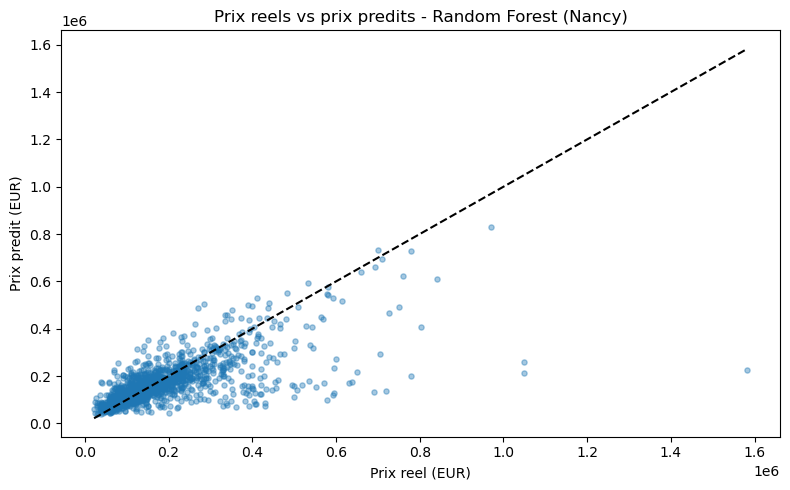

In [16]:
best_predictions = rf_pred_eur if rf_r2 >= linear_r2 else linear_pred_eur
best_name = "Random Forest" if rf_r2 >= linear_r2 else "Regression lineaire"
best_model = rf_model if rf_r2 >= linear_r2 else linear_model

plt.figure(figsize=(8, 5))
plt.scatter(y_test_eur, best_predictions, alpha=0.4, s=14)

minimum = min(y_test_eur.min(), best_predictions.min())
maximum = max(y_test_eur.max(), best_predictions.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", color="black")

plt.xlabel("Prix reel (EUR)")
plt.ylabel("Prix predit (EUR)")
plt.title(f"Prix reels vs prix predits - {best_name} (Nancy)")
plt.tight_layout()
plt.savefig("prix_reels_vs_predits.png", dpi=120)
plt.show()


## 10. Importance des variables (Random Forest)

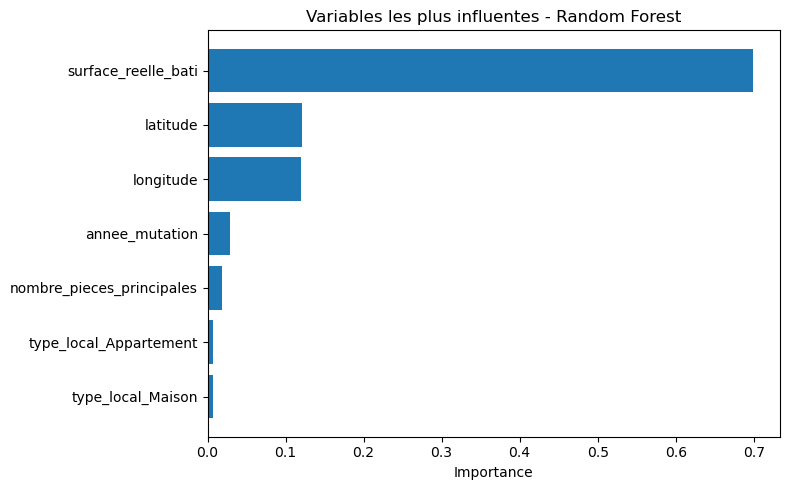

In [17]:
feature_names = (
    numeric_features +
    list(rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features))
)
importances = rf_model.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"variable": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(imp_df["variable"], imp_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Variables les plus influentes - Random Forest")
plt.tight_layout()
plt.show()


## 11. Exemple de prédiction

In [18]:
# Coordonnees d'un appartement pres du centre-ville de Nancy (Place Stanislas, code postal 54000)
nouveau_bien = pd.DataFrame({
    "surface_reelle_bati": [65],
    "nombre_pieces_principales": [3],
    "type_local": ["Appartement"],
    "longitude": [6.1815],
    "latitude": [48.6935],
    "annee_mutation": [2024]
})

prediction = np.expm1(best_model.predict(nouveau_bien))[0]
print(f"Modele selectionne : {best_name}")
print(f"Prix estime pour un appartement de 65 m2, 3 pieces, pres du centre de Nancy, en 2024 : {prediction:,.0f} EUR")


Modele selectionne : Random Forest
Prix estime pour un appartement de 65 m2, 3 pieces, pres du centre de Nancy, en 2024 : 177,374 EUR


## 12. Conclusion

Ce projet met en œuvre une démarche complète de Data Science sur des **données réelles** :

- collecte et nettoyage de données ouvertes (DVF) ;
- exploration et compréhension du marché immobilier nancéien ;
- encodage des variables catégorielles (type de bien, code postal) ;
- comparaison de deux modèles de régression (linéaire et Random Forest) ;
- évaluation par MAE, RMSE et R², analyse des variables les plus influentes ;
- utilisation du modèle pour estimer le prix d'un nouveau bien.

### Compétences mobilisées

**Python · Pandas · NumPy · Matplotlib · Scikit-learn · Statistiques · Régression · Machine Learning · Données ouvertes (open data)**

### Limites

Le jeu DVF ne renseigne pas l'état intérieur du bien, l'étage, l'exposition ou la présence d'un ascenseur, ce qui limite la précision atteignable. Le code postal est utilisé comme approximation grossière de la localisation ; une géolocalisation plus fine (quartier, distance au centre) améliorerait probablement les résultats.
